# Training SAC Agent for Autonomous Driving using Highway-Env

This notebook demonstrates how to train a Soft Actor-Critic (SAC) agent for autonomous driving using the Highway-Env environment from Farama Foundation. We'll use Stable Baselines3 for the SAC implementation and Gymnasium for the environment interface.

## Overview
- **Environment**: Highway-Env (2D autonomous driving simulation)
- **Algorithm**: Soft Actor-Critic (SAC)
- **Library**: Stable Baselines3
- **Framework**: Gymnasium

## 1. Installation

First, let's install the required packages:

In [ ]:
!pip install gymnasium highway-env stable-baselines3[extra]

## 2. Import Libraries

In [5]:
import gymnasium as gym
import highway_env
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback
import torch as th

# For rendering in Jupyter notebooks
%matplotlib inline

## 3. Environment Setup

Let's create and configure our highway environment:

In [8]:
import gymnasium as gym
import highway_env

# Create env
env = gym.make("highway-fast-v0", render_mode="rgb_array")

# Access the unwrapped env
raw_env = env.unwrapped  # <-- this is the HighwayEnv instance
raw_env.configure({
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 15,
        "features": ["presence", "x", "y", "vx", "vy", "cos_h", "sin_h"],
        "features_range": {
            "x": [-100, 100],
            "y": [-100, 100],
            "vx": [-20, 20],
            "vy": [-20, 20],
        },
        "absolute": False,
        "order": "sorted",
    },
    "action": {
        "type": "ContinuousAction",
    },
    "duration": 40,
    "simulation_frequency": 15,
    "policy_frequency": 1,
    "collision_reward": -1,
    "high_speed_reward": 0.4,
    "right_lane_reward": 0,
    "lanes_count": 4,
    "vehicles_count": 50,
    "controlled_vehicles": 1,
    "ego_spacing": 2,
    "vehicles_density": 1,
    "offscreen_rendering": True,
    "normalize_reward": True,
})

raw_env.reset()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


(array([[ 1.        ,  1.        ,  0.        ,  1.        ,  0.        ,
          1.        ,  0.        ],
        [ 1.        ,  0.2181318 ,  0.        , -0.164965  ,  0.        ,
          1.        ,  0.        ],
        [ 1.        ,  0.42041224,  0.08      , -0.10702436,  0.        ,
          1.        ,  0.        ],
        [ 1.        ,  0.6222886 ,  0.08      , -0.1318524 ,  0.        ,
          1.        ,  0.        ],
        [ 1.        ,  0.84891075,  0.08      , -0.07344567,  0.        ,
          1.        ,  0.        ],
        [ 1.        ,  1.        ,  0.04      , -0.19941162,  0.        ,
          1.        ,  0.        ],
        [ 1.        ,  1.        ,  0.        , -0.05204485,  0.        ,
          1.        ,  0.        ],
        [ 1.        ,  1.        ,  0.12      , -0.132801  ,  0.        ,
          1.        ,  0.        ],
        [ 1.        ,  1.        ,  0.        , -0.16757374,  0.        ,
          1.        ,  0.        ],
        [ 

## 4. Environment Visualization

Let's visualize the environment to understand what our agent will be working with:

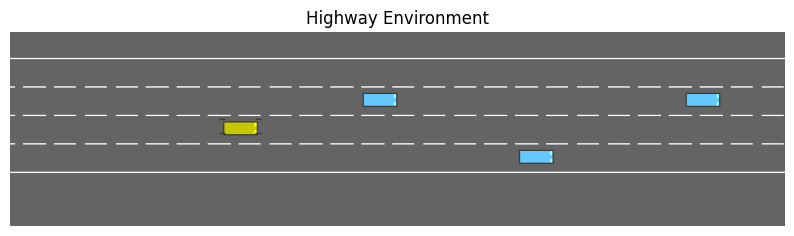

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
obs, info = env.reset()  # Gymnasium returns (obs, info) now
img = env.render()
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title("Highway Environment")
plt.axis('off')
plt.show()

## 5. SAC Model Creation

Now we'll create our SAC model with appropriate hyperparameters for the highway environment:

In [11]:
# Create the SAC model
model = SAC(
    "MlpPolicy",
    env,
    verbose=1,
    buffer_size=15000,
    learning_rate=5e-4,
    batch_size=64,
    gamma=0.8,
    tau=0.02,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",
    learning_starts=100,
    target_update_interval=50,
    policy_kwargs=dict(net_arch=[256, 256]),
    device="auto"
)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 6. Training Setup

Let's set up our training process with evaluation callbacks:

In [13]:
# Create evaluation environment
eval_env = gym.make("highway-fast-v0")
eval_env.unwrapped.configure(env.unwrapped.config)  # unwrapped here
eval_env.reset()

# Create evaluation callback
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./logs/best_model",
    log_path="./logs/",
    eval_freq=10000,
    deterministic=True,
    render=False
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 7. Model Training

Now we'll train our SAC agent. For demonstration purposes, we'll use a moderate number of timesteps:

In [ ]:
# Train the model
print("Starting training...")
model.learn(
    total_timesteps=int(5e4),  # 50,000 timesteps
    callback=eval_callback,
    log_interval=4,
    tb_log_name="SAC_highway"
)

# Save the model
model.save("sac_highway_model")
print("Training completed and model saved!")

Starting training...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 40       |
|    ep_rew_mean     | 3.23     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 3        |
|    time_elapsed    | 51       |
|    total_timesteps | 160      |
| train/             |          |
|    actor_loss      | -3.08    |
|    critic_loss     | 0.0792   |
|    ent_coef        | 0.971    |
|    ent_coef_loss   | -0.0986  |
|    learning_rate   | 0.0005   |
|    n_updates       | 59       |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 40       |
|    ep_rew_mean     | 3.11     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 3        |
|    time_elapsed    | 102      |
|    total_timesteps | 320      |
| train/             |          |
|    actor_loss      | -4.55    |
|    critic_loss     | 0.046    |
|    ent_coef        | 0.897    |
|    ent_coef_loss   | -0.366   |
|    learning_rate   | 0.0005   |
|    n_updates       | 219      |
---------------------------------


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 40       |
|    ep_rew_mean     | 5.93     |
| time/              |          |
|    episodes        | 124      |
|    fps             | 3        |
|    time_elapsed    | 1580     |
|    total_timesteps | 4960     |
| train/             |          |
|    actor_loss      | -1.37    |
|    critic_loss     | 0.0509   |
|    ent_coef        | 0.0915   |
|    ent_coef_loss   | -7.11    |
|    learning_rate   | 0.0005   |
|    n_updates       | 4859     |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 40       |
|    ep_rew_mean     | 6.39     |
| time/              |          |
|    episodes        | 128      |
|    fps             | 3        |
|    time_elapsed    | 1630     |
|    total_timesteps | 5120     |
| train/             |          |
|    actor_loss      | -1.29    |
|    critic_loss     | 0.0466   |
|    ent_coef        | 0.0852   |
|    ent_coef_loss   | -7.21    |
|    learning_rate   | 0.0005   |
|    n_updates       | 5019     |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 8. Model Evaluation

Let's evaluate our trained model by running it in the environment:

In [ ]:
# Load the trained model (if needed)
# model = SAC.load("sac_highway_model")

# Create a new environment for visualization
eval_env = gym.make("highway-fast-v0", render_mode="rgb_array")
eval_env.configure(env.unwrapped.config)

# Run the trained agent
obs, info = eval_env.reset()
done = False
total_reward = 0
step_count = 0

print("Running trained agent...")
while not done and step_count < 100:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    done = terminated or truncated
    step_count += 1
    
    # Render every 10 steps to create a visualization sequence
    if step_count % 10 == 0:
        img = eval_env.render()
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.title(f"Step {step_count} | Reward: {total_reward:.2f}")
        plt.axis('off')
        plt.show()

print(f"Episode finished after {step_count} steps with total reward: {total_reward:.2f}")

## 9. Performance Analysis

Let's run multiple episodes to analyze the performance of our trained agent:

In [ ]:
# Evaluate the agent over multiple episodes
num_episodes = 10
rewards = []
episode_lengths = []

for episode in range(num_episodes):
    obs, info = eval_env.reset()
    done = False
    total_reward = 0
    step_count = 0
    
    while not done and step_count < 100:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        done = terminated or truncated
        step_count += 1
    
    rewards.append(total_reward)
    episode_lengths.append(step_count)
    print(f"Episode {episode+1}: Reward = {total_reward:.2f}, Length = {step_count}")

# Calculate statistics
mean_reward = np.mean(rewards)
std_reward = np.std(rewards)
mean_length = np.mean(episode_lengths)

print(f"\nPerformance Summary:")
print(f"Mean Reward: {mean_reward:.2f} ± {std_reward:.2f}")
print(f"Mean Episode Length: {mean_length:.2f}")

## 10. Visualization of Results

Let's create some plots to visualize the agent's performance:

In [ ]:
# Plot reward distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(rewards, bins=10, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Total Reward')
plt.ylabel('Frequency')
plt.title('Distribution of Episode Rewards')
plt.axvline(mean_reward, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_reward:.2f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(episode_lengths, bins=10, alpha=0.7, color='lightgreen', edgecolor='black')
plt.xlabel('Episode Length')
plt.ylabel('Frequency')
plt.title('Distribution of Episode Lengths')
plt.axvline(mean_length, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_length:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

## 11. Conclusion

In this notebook, we've successfully:

1. Set up a Highway-Env environment for autonomous driving simulation
2. Configured and trained a SAC agent using Stable Baselines3
3. Evaluated the trained agent's performance
4. Visualized the results

### Key Takeaways:

- **SAC** is well-suited for continuous control tasks like autonomous driving
- **Highway-Env** provides a realistic 2D driving simulation environment
- **Stable Baselines3** offers an easy-to-use implementation of state-of-the-art RL algorithms
- The agent learned to navigate traffic, avoid collisions, and maintain reasonable speeds

### Possible Improvements:

1. **Hyperparameter Tuning**: Experiment with different learning rates, network architectures, and SAC-specific parameters
2. **Training Duration**: Increase training time for better performance
3. **Environment Complexity**: Try more complex environments like intersection or parking scenarios
4. **Algorithm Comparison**: Compare SAC with other algorithms like PPO or TD3
5. **Reward Shaping**: Modify the reward function to encourage specific driving behaviors

This implementation provides a solid foundation for autonomous driving research using reinforcement learning.

## 12. Further Experiments (Optional)

Here are some suggestions for extending this work:

In [ ]:
# Example: Try a different environment
# env_merge = gym.make("merge-v0", render_mode="rgb_array")
# model_merge = SAC("MlpPolicy", env_merge, verbose=1)
# model_merge.learn(total_timesteps=int(2e4))

# Example: Try different hyperparameters
# model_tuned = SAC(
#     "MlpPolicy",
#     env,
#     verbose=1,
#     learning_rate=1e-3,
#     buffer_size=50000,
#     batch_size=128,
#     ent_coef="auto_0.1",
#     policy_kwargs=dict(net_arch=[512, 512, 512])
# )
# model_tuned.learn(total_timesteps=int(5e4))